In [15]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt
plt.rcParams['text.usetex'] = True

In [16]:
from sklearn.neural_network import MLPClassifier

In [17]:
import uproot
import pandas as pd
import numpy as np
import json
from scipy.optimize import curve_fit, minimize
from scipy.stats import argus
from scipy.integrate import quad
from numpy import  log, sqrt, exp, pi, e
import multiprocessing
import os
from numba import njit
from source import *


In [18]:
dataframes = []
for filename in os.listdir("end_mc"):
    if filename.endswith('.root'):
        filepath = os.path.join("end_mc", filename)
        with uproot.open(filepath) as file:
            tupl2 = file['h1']
            tkeys = tupl2.keys()
            print(f"Keys in {filename}: {tkeys}")
            mc = tupl2.arrays(library='pd')
            mc['source_file'] = filename
            dataframes.append(mc)

mc = pd.concat(dataframes, ignore_index=True)
mc = mc[(np.abs(mc.rml - Lamc_m) < 0.5)]

Keys in 11.root: ['en', 'nen', 'ecm', 'pcm', 'p', 'np', 'ntr', 'en_gam', 'enc_gam', 'count_ga', 'chxc', 'ppi', 'mpi', 'pxc', 'tr', 'npxc', 'nmxc', 'mxc', 'cmxca', 'ncmxca', 'chach', 'pach', 'mach', 'nmach', 'machdt', 'Dpia', 'chl', 'ml', 'pl', 'ang_l_xc', 'nang_l_x', 'ang_lc_l', 'ang_l_p', 'p_prot', 'p_lam', 'rmn', 'nrmn', 'rml', 'nrml', 'pn', 'npn', 'rmnu', 'nrmnu', 'fnrmnu', 'chi', 'q', 'Id', 'fox']
Keys in 13.root: ['en', 'nen', 'ecm', 'pcm', 'p', 'np', 'ntr', 'en_gam', 'enc_gam', 'count_ga', 'chxc', 'ppi', 'mpi', 'pxc', 'tr', 'npxc', 'nmxc', 'mxc', 'cmxca', 'ncmxca', 'chach', 'pach', 'mach', 'nmach', 'machdt', 'Dpia', 'chl', 'ml', 'pl', 'ang_l_xc', 'nang_l_x', 'ang_lc_l', 'ang_l_p', 'p_prot', 'p_lam', 'rmn', 'nrmn', 'rml', 'nrml', 'pn', 'npn', 'rmnu', 'nrmnu', 'fnrmnu', 'chi', 'q', 'Id', 'fox']
Keys in 15.root: ['en', 'nen', 'ecm', 'pcm', 'p', 'np', 'ntr', 'en_gam', 'enc_gam', 'count_ga', 'chxc', 'ppi', 'mpi', 'pxc', 'tr', 'npxc', 'nmxc', 'mxc', 'cmxca', 'ncmxca', 'chach', 'pach', 

In [19]:
lern = mc[(mc.chl >= 3)]
lern.head(10)

,en,nen,ecm,pcm,p,np,ntr,en_gam,enc_gam,count_ga,...,pn,npn,rmnu,nrmnu,fnrmnu,chi,q,Id,fox,source_file
1,10.577520,10.577881,10.57617,4.49887,0.004941,0.004583,0.0,0.0,0.0,0.0,...,0.004770,0.004346,0.019913,0.018517,1.356316e-19,0.003458,0.864748,1.356316e-19,0.639177,11.root
3,9.913109,9.968087,10.57617,4.49887,1.306395,1.279254,0.0,0.0,0.0,0.0,...,1.668330,1.614552,-0.365056,-0.449121,1.356316e-19,26.818672,0.692866,1.356316e-19,0.404817,11.root
14,10.577672,10.574245,10.57617,4.49887,0.019665,0.021616,0.0,0.0,0.0,0.0,...,0.020232,0.023217,0.027296,0.037322,1.356316e-19,0.426953,0.815131,1.356316e-19,0.633239,11.root
15,10.498281,10.499936,10.57617,4.49887,0.119793,0.121701,0.0,0.0,0.0,0.0,...,0.106587,0.108879,0.046877,0.041909,1.356316e-19,0.080093,1.131353,1.356316e-19,0.580821,11.root
18,10.550218,10.572403,10.57617,4.49887,0.012055,0.014480,0.0,0.0,0.0,0.0,...,0.007002,0.013985,0.034907,0.017187,1.356316e-19,9.544296,0.811653,1.356316e-19,0.619702,11.root
24,10.311731,10.352401,10.57617,4.49887,0.227943,0.293287,0.0,0.0,0.0,0.0,...,0.244524,0.290183,0.131321,0.003823,1.356316e-19,90.654831,0.626964,1.356316e-19,0.522726,11.root
25,10.263288,10.353415,10.57617,4.49887,0.155161,0.274074,0.0,0.0,0.0,0.0,...,0.191209,0.252188,0.292002,0.045004,1.356316e-19,542.860352,0.626964,1.356316e-19,0.522726,11.root
26,10.163292,10.211190,10.57617,4.49887,0.373600,0.429060,0.0,0.0,0.0,0.0,...,0.387738,0.433371,0.311563,0.011628,1.356316e-19,52.626419,1.153912,1.356316e-19,0.594211,11.root
29,10.459247,10.549156,10.57617,4.49887,0.118949,0.129984,0.0,0.0,0.0,0.0,...,0.079603,0.129222,0.162900,0.040324,1.356316e-19,46.961235,1.573354,1.356316e-19,0.500504,11.root
30,10.506942,10.535388,10.57617,4.49887,0.083136,0.090033,0.0,0.0,0.0,0.0,...,0.118058,0.109923,0.365702,0.070536,1.356316e-19,11.686526,0.227221,1.356316e-19,0.613268,11.root


In [20]:
Names = ['rml', 'ecm', 'pcm', 'ppi', 'mpi', 'Dpia', 'pach', 'mach', 'nmach', 'nmxc', 'mxc', 'pxc', 'npxc', 'cmxca', 'ncmxca', 'chxc', 'fox', 'tr']

In [21]:
lern = lern[Names].to_numpy()
print(lern)

[[ 2.2878795  10.57617     4.4988704  ...  2.          0.63917696
   1.        ]
 [ 2.3790228  10.57617     4.4988704  ...  4.          0.40481713
   0.        ]
 [ 2.2765014  10.57617     4.4988704  ...  4.          0.63323945
   1.        ]
 ...
 [ 2.5622284  10.575175    4.4984474  ...  1.          0.4362099
   0.        ]
 [ 2.3206155  10.575175    4.4984474  ...  4.          0.5734082
   1.        ]
 [ 2.4259524  10.575175    4.4984474  ...  2.          0.39063615
   1.        ]]


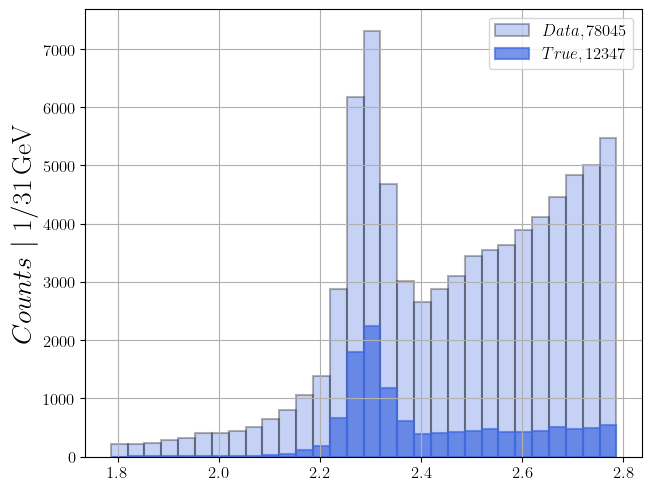

In [22]:
bins = np.linspace(Lamc_m - 0.5, Lamc_m + 0.5, 31)

plt.hist(lern[:, 0], bins=bins, alpha=0.3, label=f'$Data, {len(lern[:, 0])}$', color='royalblue', linewidth=1.5, edgecolor='black')
plt.hist(mc[(mc.chl >= 3) & (mc.tr == 1)].rml, bins=bins, alpha=0.7, label=f'$True, {len(mc[(mc.chl >= 3) & (mc.tr == 1)].rml)}$', color='royalblue', linewidth=1.5, edgecolor='royalblue')
plt.ylabel('$Counts \\ | \\ 1/31 \\, \\mathrm{GeV}$')
plt.legend()
plt.grid(True)

plt.show()


In [23]:
X = lern

X_features = X[:, :-1] 
y_target = X[:, -1].astype(int)

X_train, X_test, y_train, y_test = train_test_split(X_features, y_target, test_size=0.4, random_state=42)
X_train_fox = X_train[:, -1] 
X_train = X_train[:, :-1] 
X_test_fox = X_test[:, -1] 
X_test = X_test[:, :-1] 

In [24]:
clf = RandomForestClassifier(
    n_estimators=4000,
    max_depth=200,
    min_samples_split=3,
    min_samples_leaf=1,
    bootstrap=True,
    oob_score=True,
    n_jobs=-1,
    random_state=41,
    class_weight='balanced'
)
clf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=200,
                       min_samples_split=3, n_estimators=4000, n_jobs=-1,
                       oob_score=True, random_state=41)

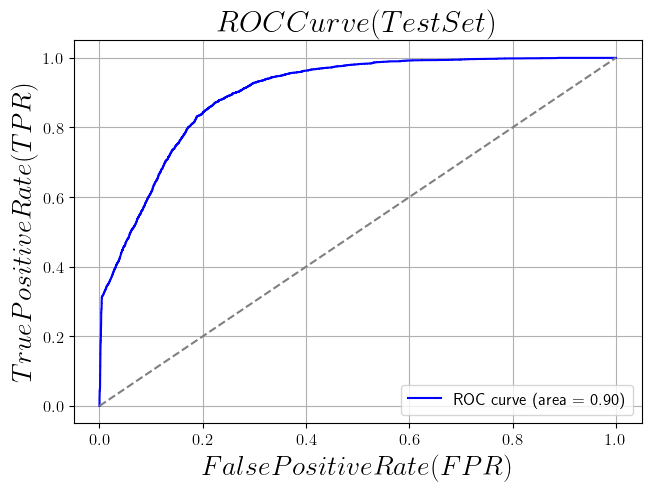

In [25]:
y_test_pred_prob = clf.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_test_pred_prob)

plt.plot(fpr, tpr, color='blue', label='ROC curve (area = %0.2f)' % auc(fpr, tpr))
plt.plot([0, 1], [0, 1], color='grey', linestyle='--')
plt.grid()
plt.xlabel('$False Positive Rate (FPR)$')
plt.ylabel('$True Positive Rate (TPR)$')
plt.title('$ROC Curve (Test Set)$')
plt.legend(loc="lower right")
plt.show()


/tmp/ipykernel_5093/587535670.py:70: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


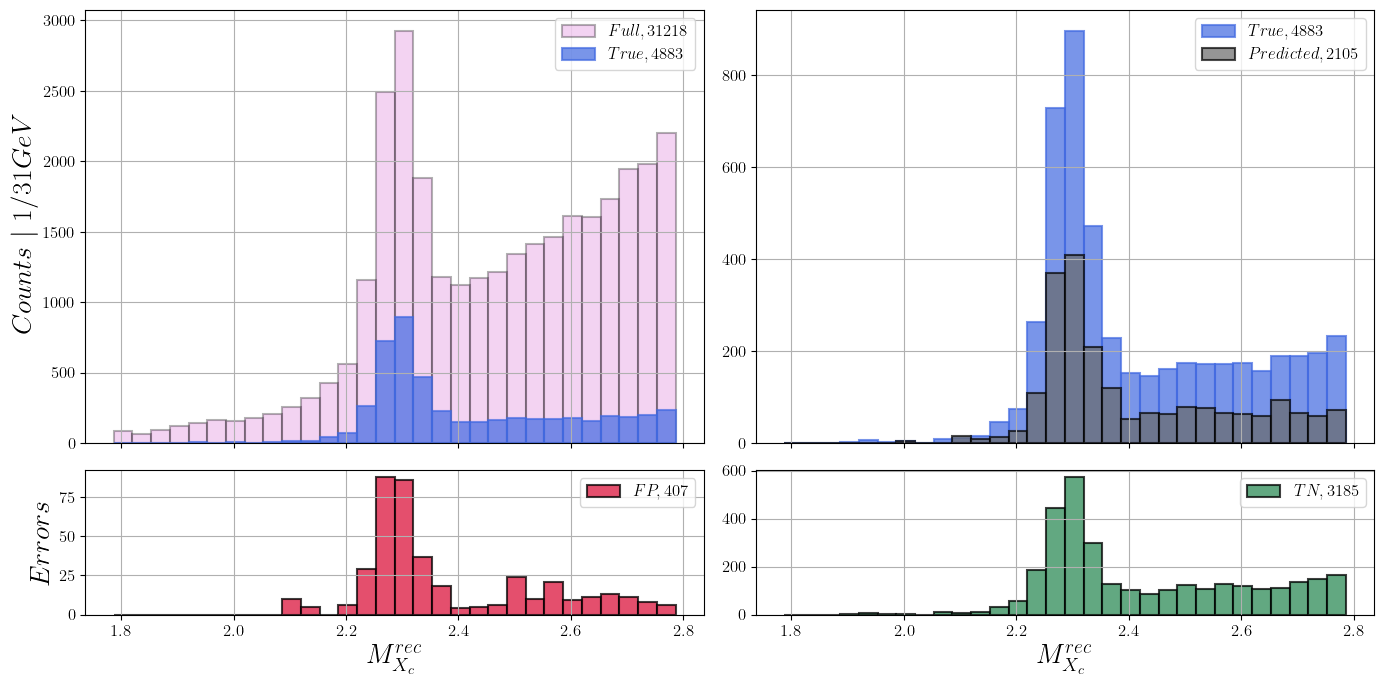

accuracy: 0.8849381766929335


In [34]:
# Предсказанная вероятность
y_test_pred_prob = clf.predict_proba(X_test)[:, 1]

# Определим порог L
L = 0.5

# Предсказания с учётом порога
y_test_pred_L = (y_test_pred_prob >= L).astype(int)

# Истинные и предсказанные индексы
true_indices = (y_test == 1)
pred_indices = (y_test_pred_L == 1)

tn = (y_test == 1) & (y_test_pred_L == 0)
fn = (y_test == 0) & (y_test_pred_L == 0)
fp = (y_test == 0) & (y_test_pred_L == 1)
tp = (y_test == 1) & (y_test_pred_L == 1)

# Отдельные индексы для TP и FP
tn_indices = (y_test == 1) & (y_test_pred_L == 0)  # True Negativ
fp_indices = (y_test == 0) & (y_test_pred_L == 1)  # False Positives

feature_index = 0

# Получаем значения для TN и FP по выбранному признаку
X_tp = X_test[tn_indices, feature_index]
X_fp = X_test[fp_indices, feature_index]

# Также выберем истинные значения
X_true = X_test[true_indices, feature_index]
X_pred = X_test[pred_indices, feature_index]

# Задаем биннинг
bins = np.linspace(Lamc_m - 0.5, Lamc_m + 0.5, 31)

# Получаем значения для гистограмм
counts_true, bin_edges = np.histogram(X_true, bins=bins)
counts_pred, _ = np.histogram(X_pred, bins=bins)

# Построение графиков
fig, ((ax1, ax3), (ax2, ax4)) = plt.subplots(2, 2, gridspec_kw={'height_ratios': [3, 1]}, sharex=True, figsize=(14, 7))

# Гистограмма полного набора данных и истинных данных
ax1.hist(X_test[:, feature_index], bins=bins, alpha=0.3, label=f'$Full, {len(X_test[:, feature_index])}$', color='orchid', linewidth=1.5, edgecolor='black')
ax1.hist(X_true, bins=bins, alpha=0.7, label=f'$True, {len(X_true)}$', color='royalblue', linewidth=1.5, edgecolor='royalblue')
ax1.set_ylabel('$Counts \\ | \\ 1/31 GeV$')
ax1.legend()
ax1.grid()

# Гистограмма истинных данных и предсказанных данных
ax3.hist(X_true, bins=bins, alpha=0.7, label=f'$True, {len(X_true)}$', color='royalblue', linewidth=1.5, edgecolor='royalblue')
ax3.hist(X_pred, bins=bins, alpha=0.7, label=f'$Predicted, {len(X_pred)}$', color='dimgrey', linewidth=1.5, edgecolor='black')
ax3.legend()
ax3.grid()

# Гистограмма FP ошибок
ax2.hist(X_fp, bins=bins, label=f'$FP, {len(X_fp)}$', color='crimson', alpha=0.75, linewidth=1.5, edgecolor='black')
ax2.set_xlabel('$M_{X_c}^{rec}$')
ax2.set_ylabel('$Errors$')
ax2.legend()
ax2.grid()

# Гистограмма TN правильных предсказаний
ax4.hist(X_tp, bins=bins, label=f'$TN, {len(X_tp)}$', color='seagreen', alpha=0.75, linewidth=1.5, edgecolor='black')
ax4.set_xlabel('$M_{X_c}^{rec}$')
ax4.legend()
ax4.grid()


plt.tight_layout()
plt.show()

print(f"accuracy: {(len(X_test[tp, feature_index]) + len(X_test[fn, feature_index]))/len(X_test[:, feature_index])}")

In [27]:

def filter_and_select_max_L(X_test, X_test_fox, clf, L_threshold=0.3):
    """Зная что в ожном собитии можт присутствовать только одна истинная сомбинация, предлагается выбирать в одном событии только лучшего кандидата"""
    y_test_pred_prob = clf.predict_proba(X_test)[:, 1]
    
    df = pd.DataFrame({
        'id': np.arange(len(X_test_fox)),
        'fox': X_test_fox,
        'L': y_test_pred_prob 
    })
    
    id1 = df[df['L'] >= L_threshold]['id']
    
    id2 = df.loc[df.groupby('fox')['L'].idxmax()]['id']
    
    lier_list = np.zeros(len(X_test_fox))
    lier_list[(df['id'].isin(id1)) & (df['id'].isin(id2))] = 1
    
    return lier_list


2936 2000


/tmp/ipykernel_5093/2066648700.py:40: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


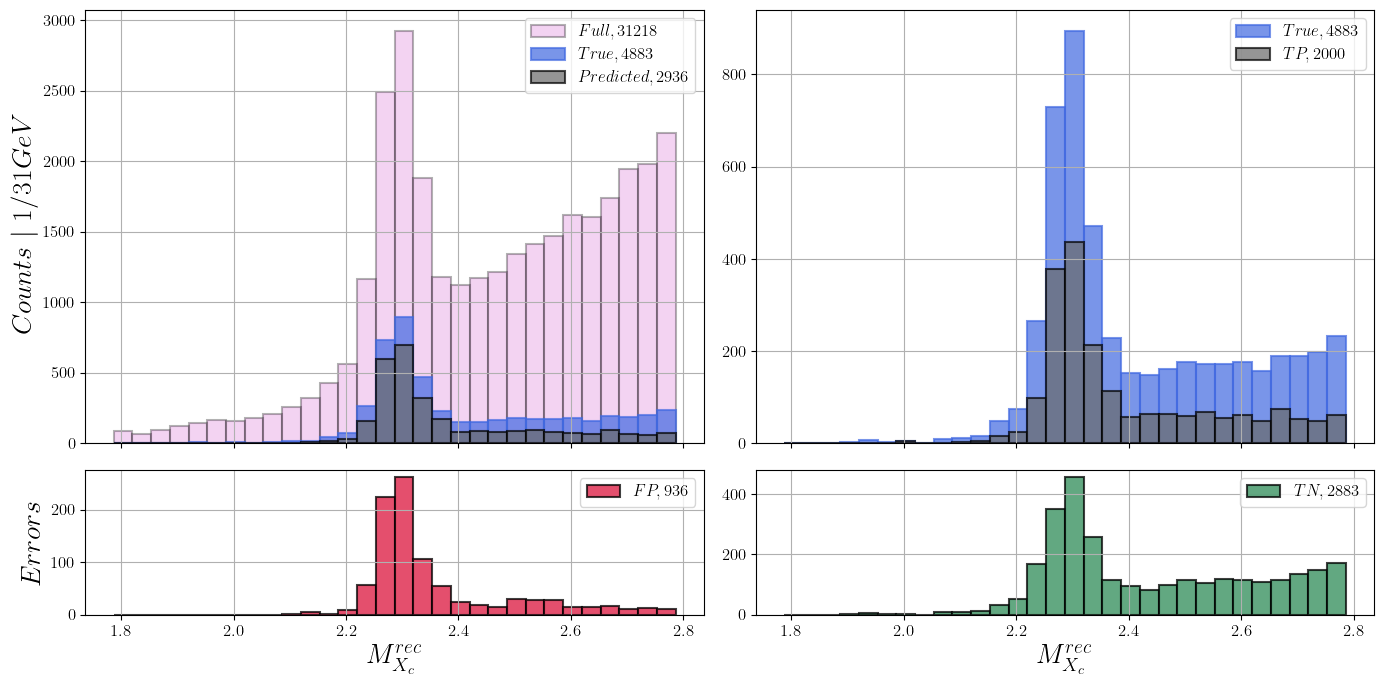

accuracy: 0.8776667307322699


In [36]:
y_test_pred_L = (filter_and_select_max_L(X_test, X_test_fox, clf, L_threshold=0.4)).astype(int)

true = (y_test == 1)
pred = (y_test_pred_L == 1)

tn = (y_test == 1) & (y_test_pred_L == 0)
fn = (y_test == 0) & (y_test_pred_L == 0)
fp = (y_test == 0) & (y_test_pred_L == 1)
tp = (y_test == 1) & (y_test_pred_L == 1)

print(np.sum(pred), np.sum(tp))

bins_x = np.linspace(X_test[:, feature_index].min(), X_test[:, feature_index].max(), 31)

fig, ((ax1, ax3), (ax2, ax4)) = plt.subplots(2, 2, gridspec_kw={'height_ratios': [3, 1]}, sharex=True, figsize=(14, 7))

ax1.hist(X_test[:, feature_index], bins=bins_x, alpha=0.3, label=f'$Full, {len(X_test[:, feature_index])}$', color='orchid', linewidth=1.5, edgecolor='black')
ax1.hist(X_test[true, feature_index], bins=bins_x, alpha=0.7, label=f'$True, {len(X_test[true, feature_index])}$', color='royalblue', linewidth=1.5, edgecolor='royalblue')
ax1.hist(X_test[pred, feature_index], bins=bins_x, alpha=0.7, label=f'$Predicted, {len(X_test[pred, feature_index])}$', color='dimgrey', linewidth=1.5, edgecolor='black')
ax1.set_ylabel('$Counts \\ | \\ 1/31 GeV$')
ax1.legend()
ax1.grid()

ax3.hist(X_test[true, feature_index], bins=bins_x, alpha=0.7, label=f'$True, {len(X_test[true, feature_index])}$', color='royalblue', linewidth=1.5, edgecolor='royalblue')
ax3.hist(X_test[tp, feature_index], bins=bins_x, alpha=0.7, label=f'$TP, {len(X_test[tp, feature_index])}$', color='dimgrey', linewidth=1.5, edgecolor='black')
ax3.legend()
ax3.grid()

ax2.hist(X_test[fp, feature_index], bins=bins_x, label=f'$FP, {len(X_test[fp, feature_index])}$', color='crimson', alpha=0.75, linewidth=1.5, edgecolor='black')
ax2.set_xlabel('$M_{X_c}^{rec}$')
ax2.set_ylabel('$Errors$')
ax2.legend()
ax2.grid()

ax4.hist(X_test[tn, feature_index], bins=bins_x, label=f'$TN, {len(X_test[tn, feature_index])}$', color='seagreen', alpha=0.75, linewidth=1.5, edgecolor='black')
ax4.set_xlabel('$M_{X_c}^{rec}$')
ax4.legend()
ax4.grid()

plt.tight_layout()
plt.show()

print(f"accuracy: {(len(X_test[tp, feature_index]) + len(X_test[fn, feature_index]))/len(X_test[:, feature_index])}")

In [320]:
all = mc[(np.abs(mc.rml - Lamc_m) < 0.5) & (mc.chl >= 3)]
X_test = all[Names].to_numpy()[:, :-1]
y_test = all[Names].to_numpy()[:, -1].astype(int)